# Deconvolve Chromatin - Refactor and Find Gamma


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_grid_compute import ChromatinGrid

chromatin_gridder = ChromatinGrid()

In [3]:
chromatin_gridder.set_gene('CLB2')

In [4]:
chromatin_gridder.create_bins_per_sample()

The histogram shape for the 2000 bp window around the TSS: (3, 20)
The shape for the middle 10 bins (1000 bp around the TSS): (3, 10)


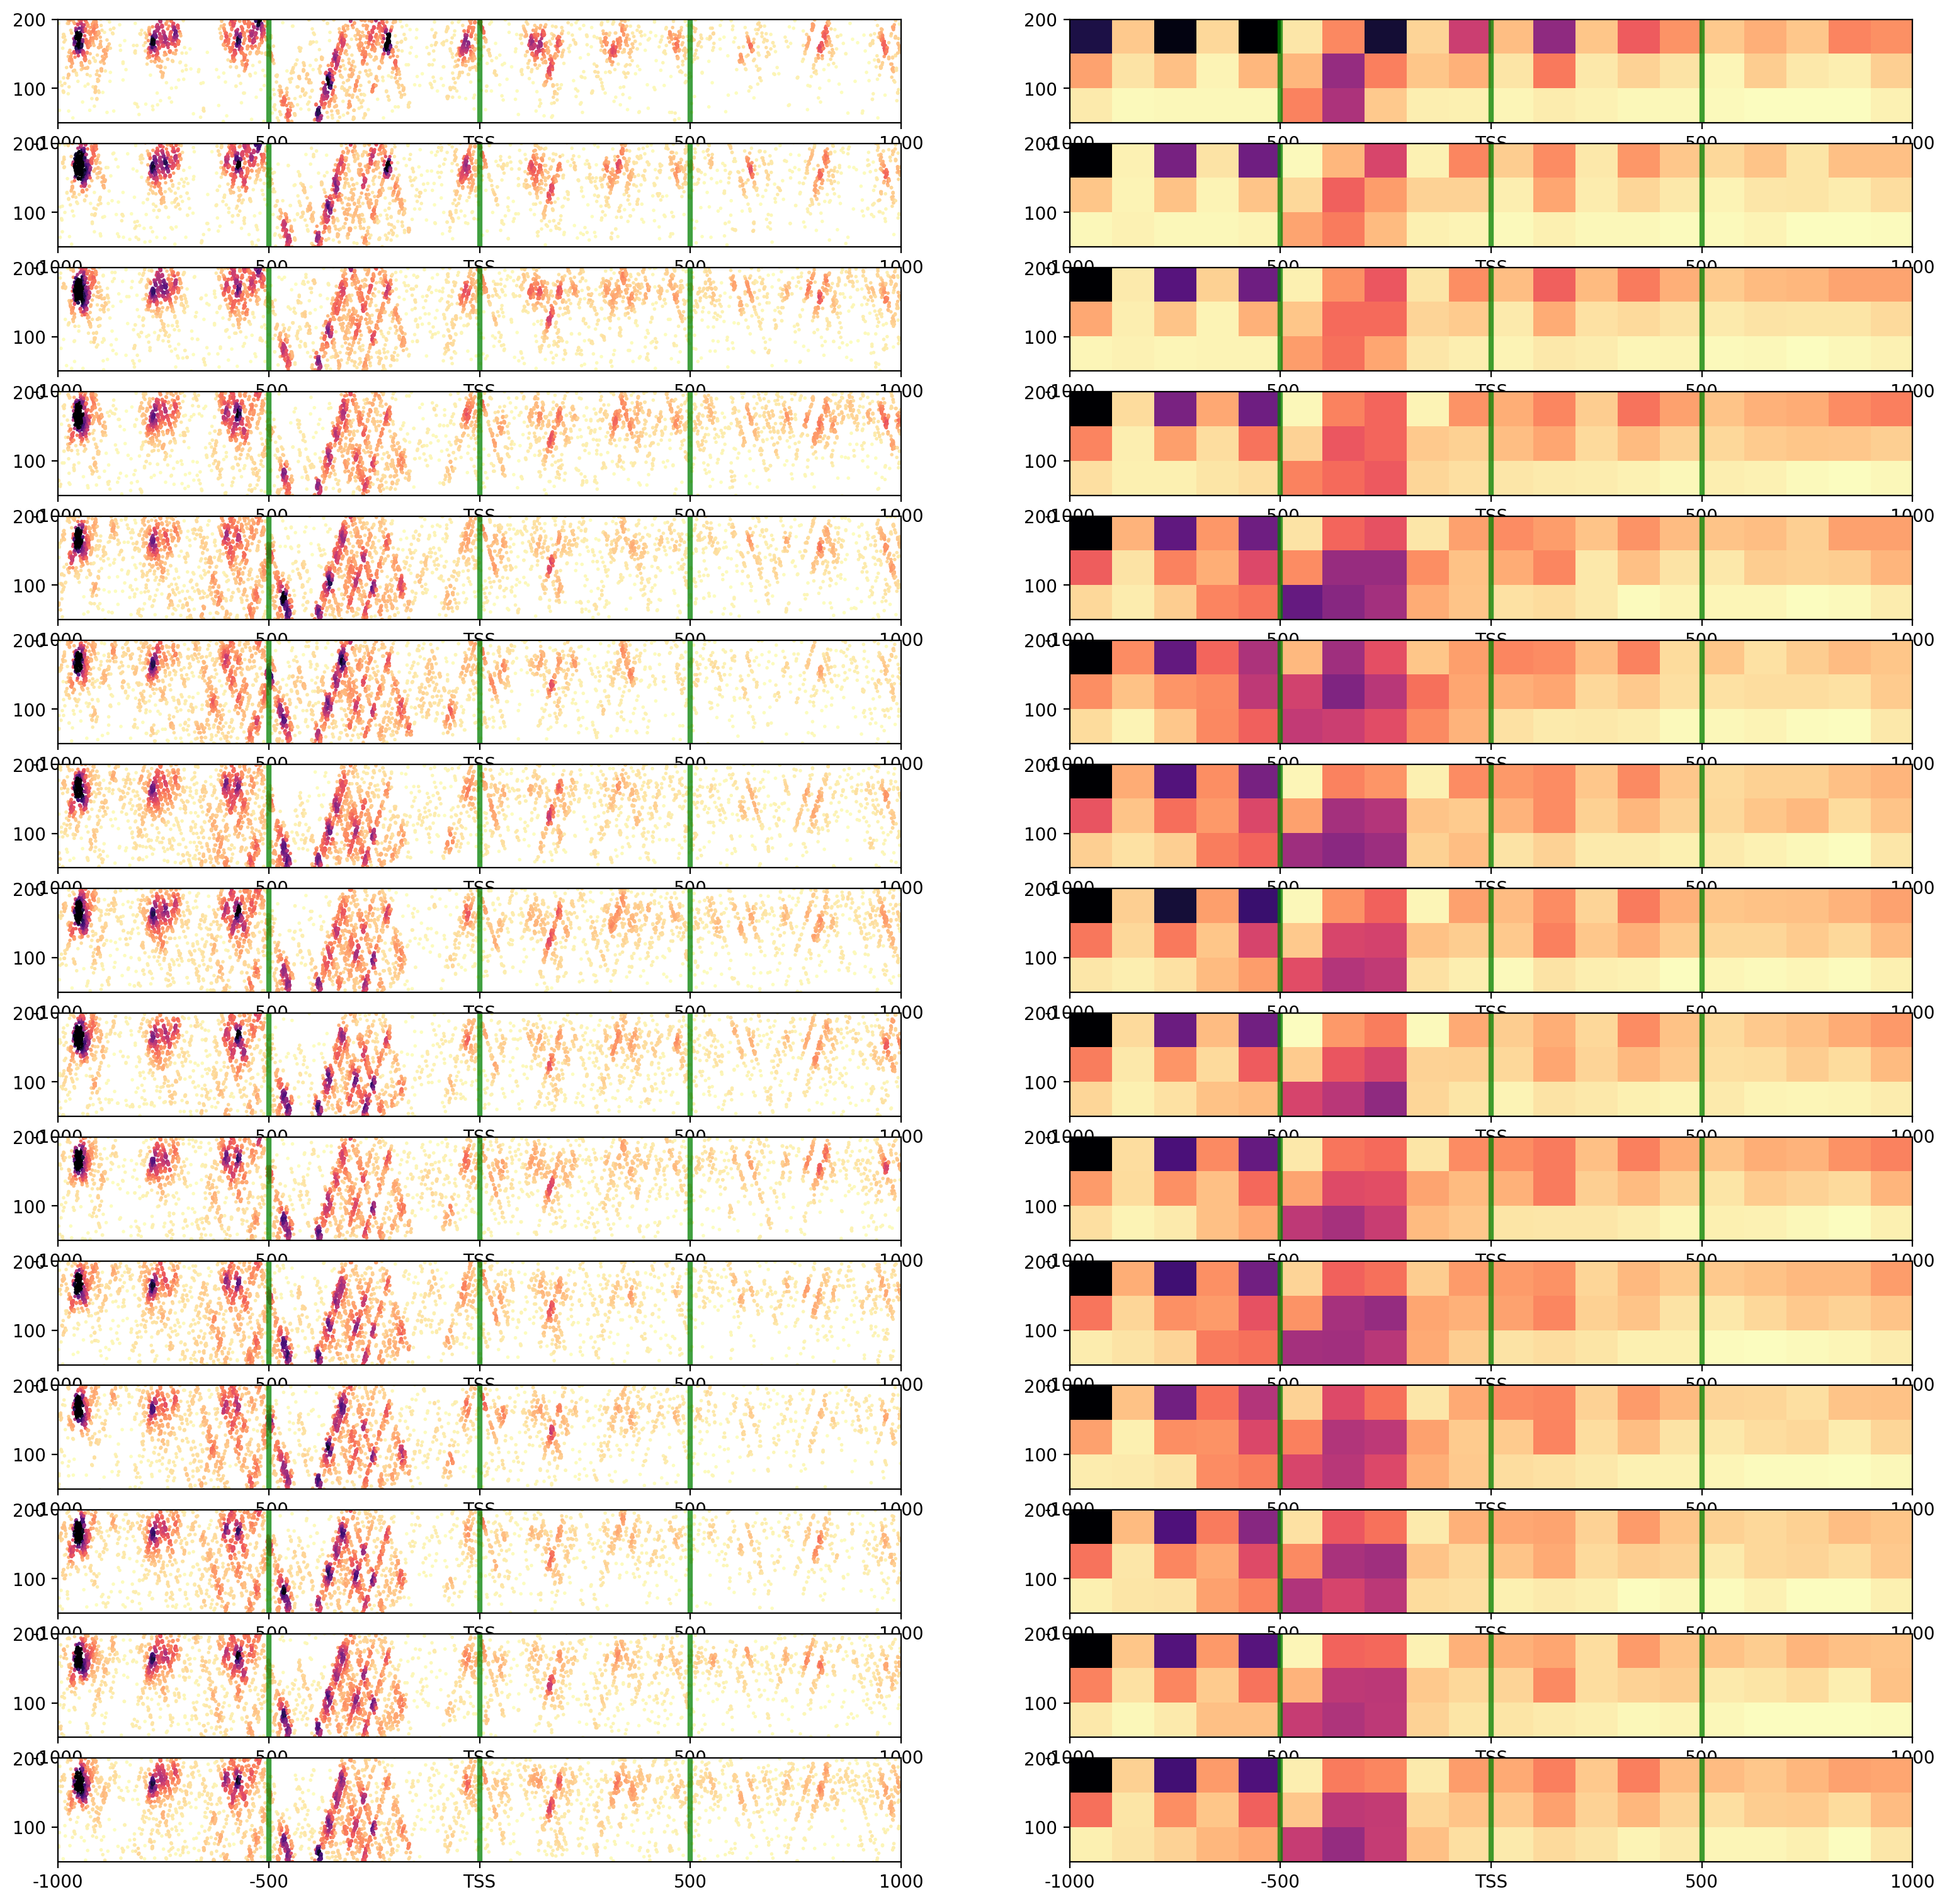

In [5]:
chromatin_gridder.plot_raw_and_grid()

The first histogram is shape: (3, 10)
Reshaping this histogram to a vector of shape: (30,)
Then, if we were to take that first vector and restore it to its original shape: (3, 10)
Now we have a data structure that we can try to deconvolve of shape: (14, 30)


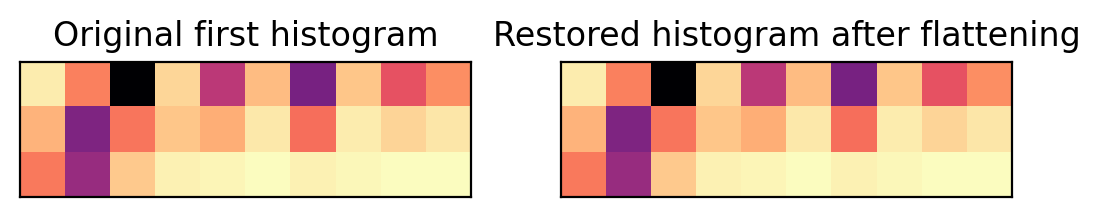

In [6]:
chromatin_gridder.create_deconvolution_matrices(plot=True)

In [7]:
from src.config import load_yl_replicate2_rg1_config, \
    load_xg_gene_expression_config
from src.model import Model

gene_name = 'CLB2'

config = load_yl_replicate2_rg1_config()
model = Model(config, gene_name, 0.04)
print("The shape of the convolution kernel matrix, H is: ", model.H.shape)

Initial branch: Recovery shape:  (14, 49)
Initial branch: postG1 shape:  (14, 79)
The shape of the convolution kernel matrix, H is:  (14, 226)


In [18]:
from src.deconvolve_chromatin import plot_deconvolved_chromatin
from src.deconvolve_chromatin import deconvolve_chromatin
from src.timer import Timer

timer = Timer()
result, f = deconvolve_chromatin(model, chromatin_gridder.deconv_hist)
print(f"Completed in {timer.get_time()}")
print(f"  The result was {result:.2f} and an F matrix of size {f.shape}")

Completed in 00:00:33.22
  The result was 3.28 and an F matrix of size (226, 30)


In [19]:
model.rn, model.sn

(25.251357722042435, 103.92825863811449)

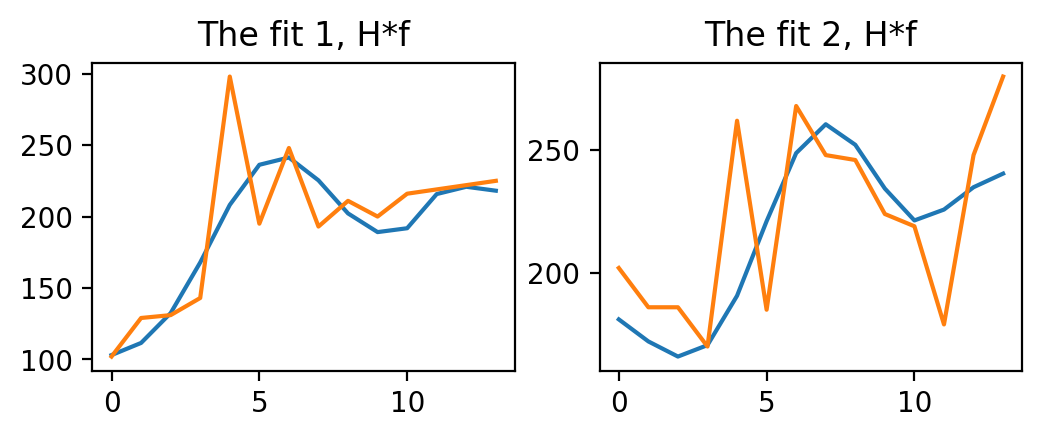

In [20]:
plot_deconvolved_chromatin(model.H, f, chromatin_gridder.deconv_hist)

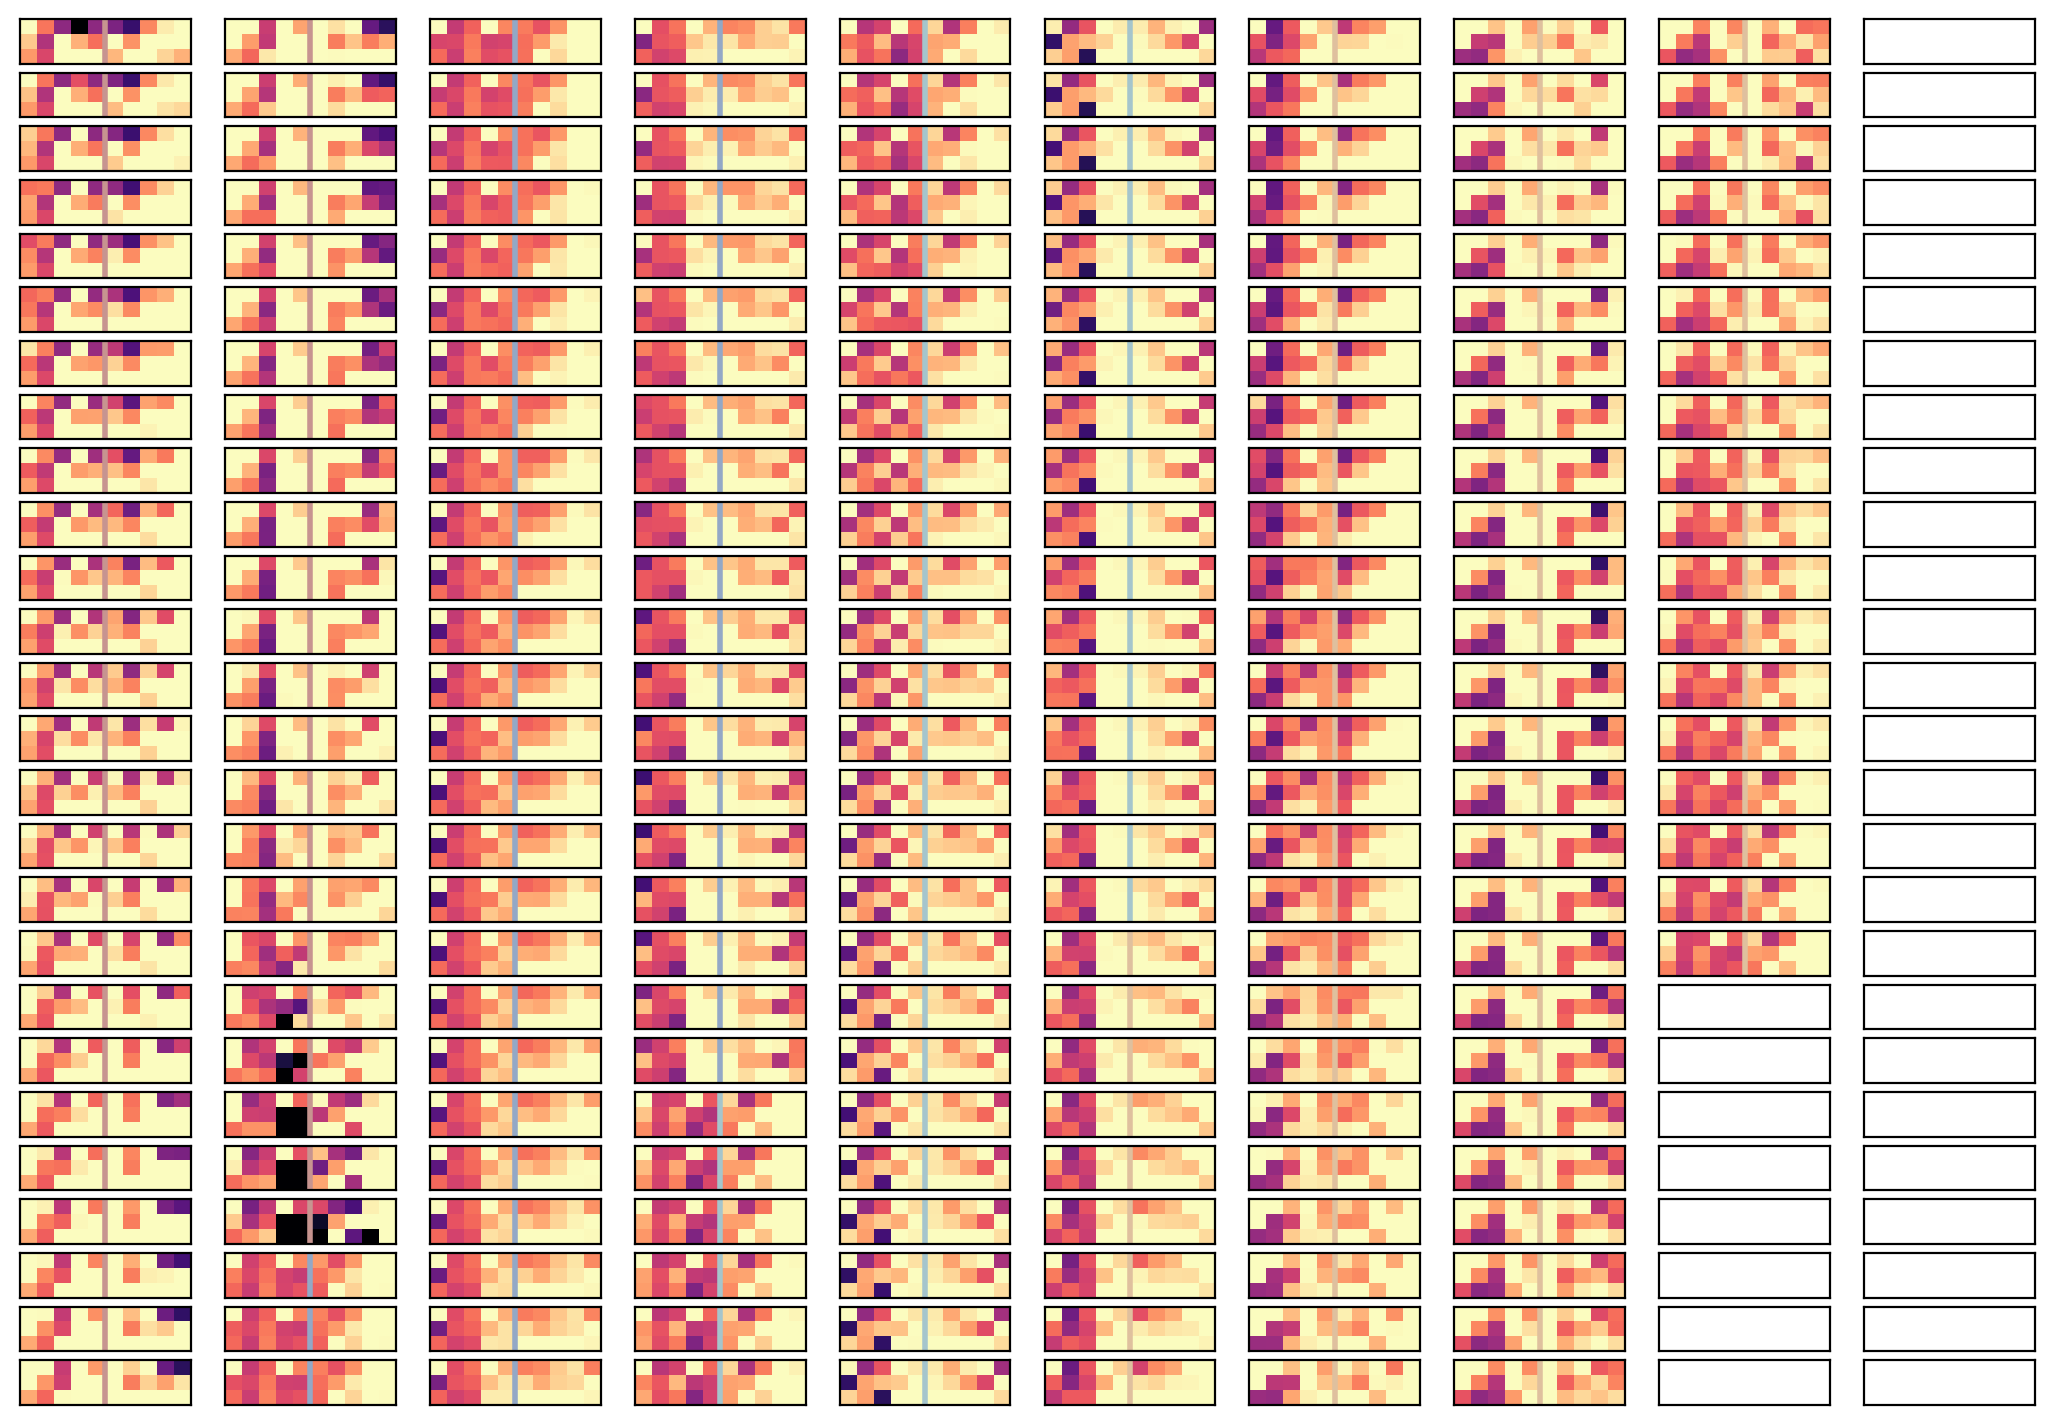

In [21]:
chromatin_gridder.create_deconvolution_plots(f, model)

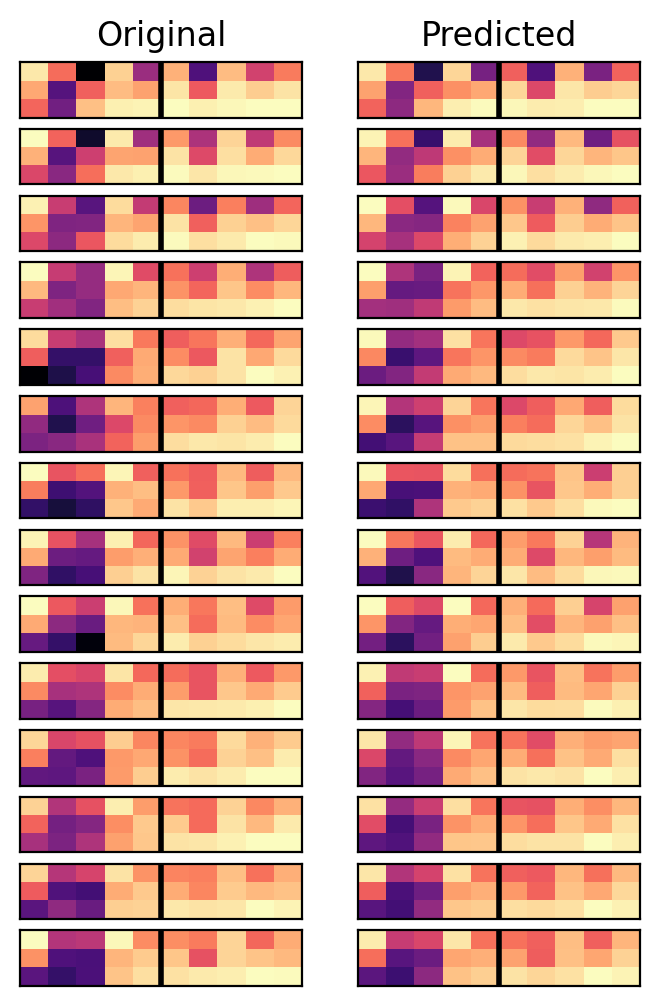

In [22]:
chromatin_gridder.plot_prediction_comparison(model, f)

In [23]:
from src.find_gamma_chromatin import FindOptimalGammaChromatin

find_gamma_chromatin = FindOptimalGammaChromatin(model, chromatin_gridder)

In [39]:
find_gamma_chromatin.find_optimal()

findOptimal
  ... base_rn = 24.5195
  ... gamma in [0.0010, 0.0100]
  ...  search left, rn_goal = 24.5995, rate = 0.3
  ...  search right, rn_goal = 34.3273, rate = 40.0
  ... rn range: [25.2514, 27.1119]
  ... search gamma in [0.0010 0.0100] for elbow
  ...   gamma = 0.001, rn = 25.25, sn = 103.9
  ...   gamma = 0.0019, rn = 25.63, sn = 77.15
  ...   gamma = 0.0028, rn = 25.92, sn = 66.85
  ...   gamma = 0.0037, rn = 26.26, sn = 57.93
  ...   gamma = 0.0046, rn = 26.43, sn = 50.1
  ...   gamma = 0.0055, rn = 26.6, sn = 46.16
  ...   gamma = 0.0064, rn = 26.68, sn = 50.61
  ...   gamma = 0.0073, rn = 26.88, sn = 44.93
  ...   gamma = 0.0082, rn = 26.99, sn = 44.07
  ...   gamma = 0.0091, rn = 26.96, sn = 43.31
  ...   gamma = 0.01, rn = 27.11, sn = 41.52
The x_grad1 is: [0.38038039 0.33646751 0.31367788 0.25478659 0.17230678 0.22265618
 0.19076236 0.11611321 0.12617253]
The x_grad2 is: [-0.04391288 -0.03335125 -0.04084046 -0.07068555 -0.01606521  0.00922779
 -0.05327148 -0.03229492  0.

(1,
 array([25.25135772, 25.63173811, 25.92429273, 26.25909388, 26.43386591,
        26.60370743, 26.87917827, 26.98523216, 27.11140469]),
 array([103.92825864,  77.15468973,  66.85385315,  57.92778248,
         50.096312  ,  46.16459412,  44.92754002,  44.07401531,
         41.51809905]),
 array([0.001 , 0.0019, 0.0028, 0.0037, 0.0046, 0.0055, 0.0073, 0.0082,
        0.01  ]),
 0.0055000000000000005)

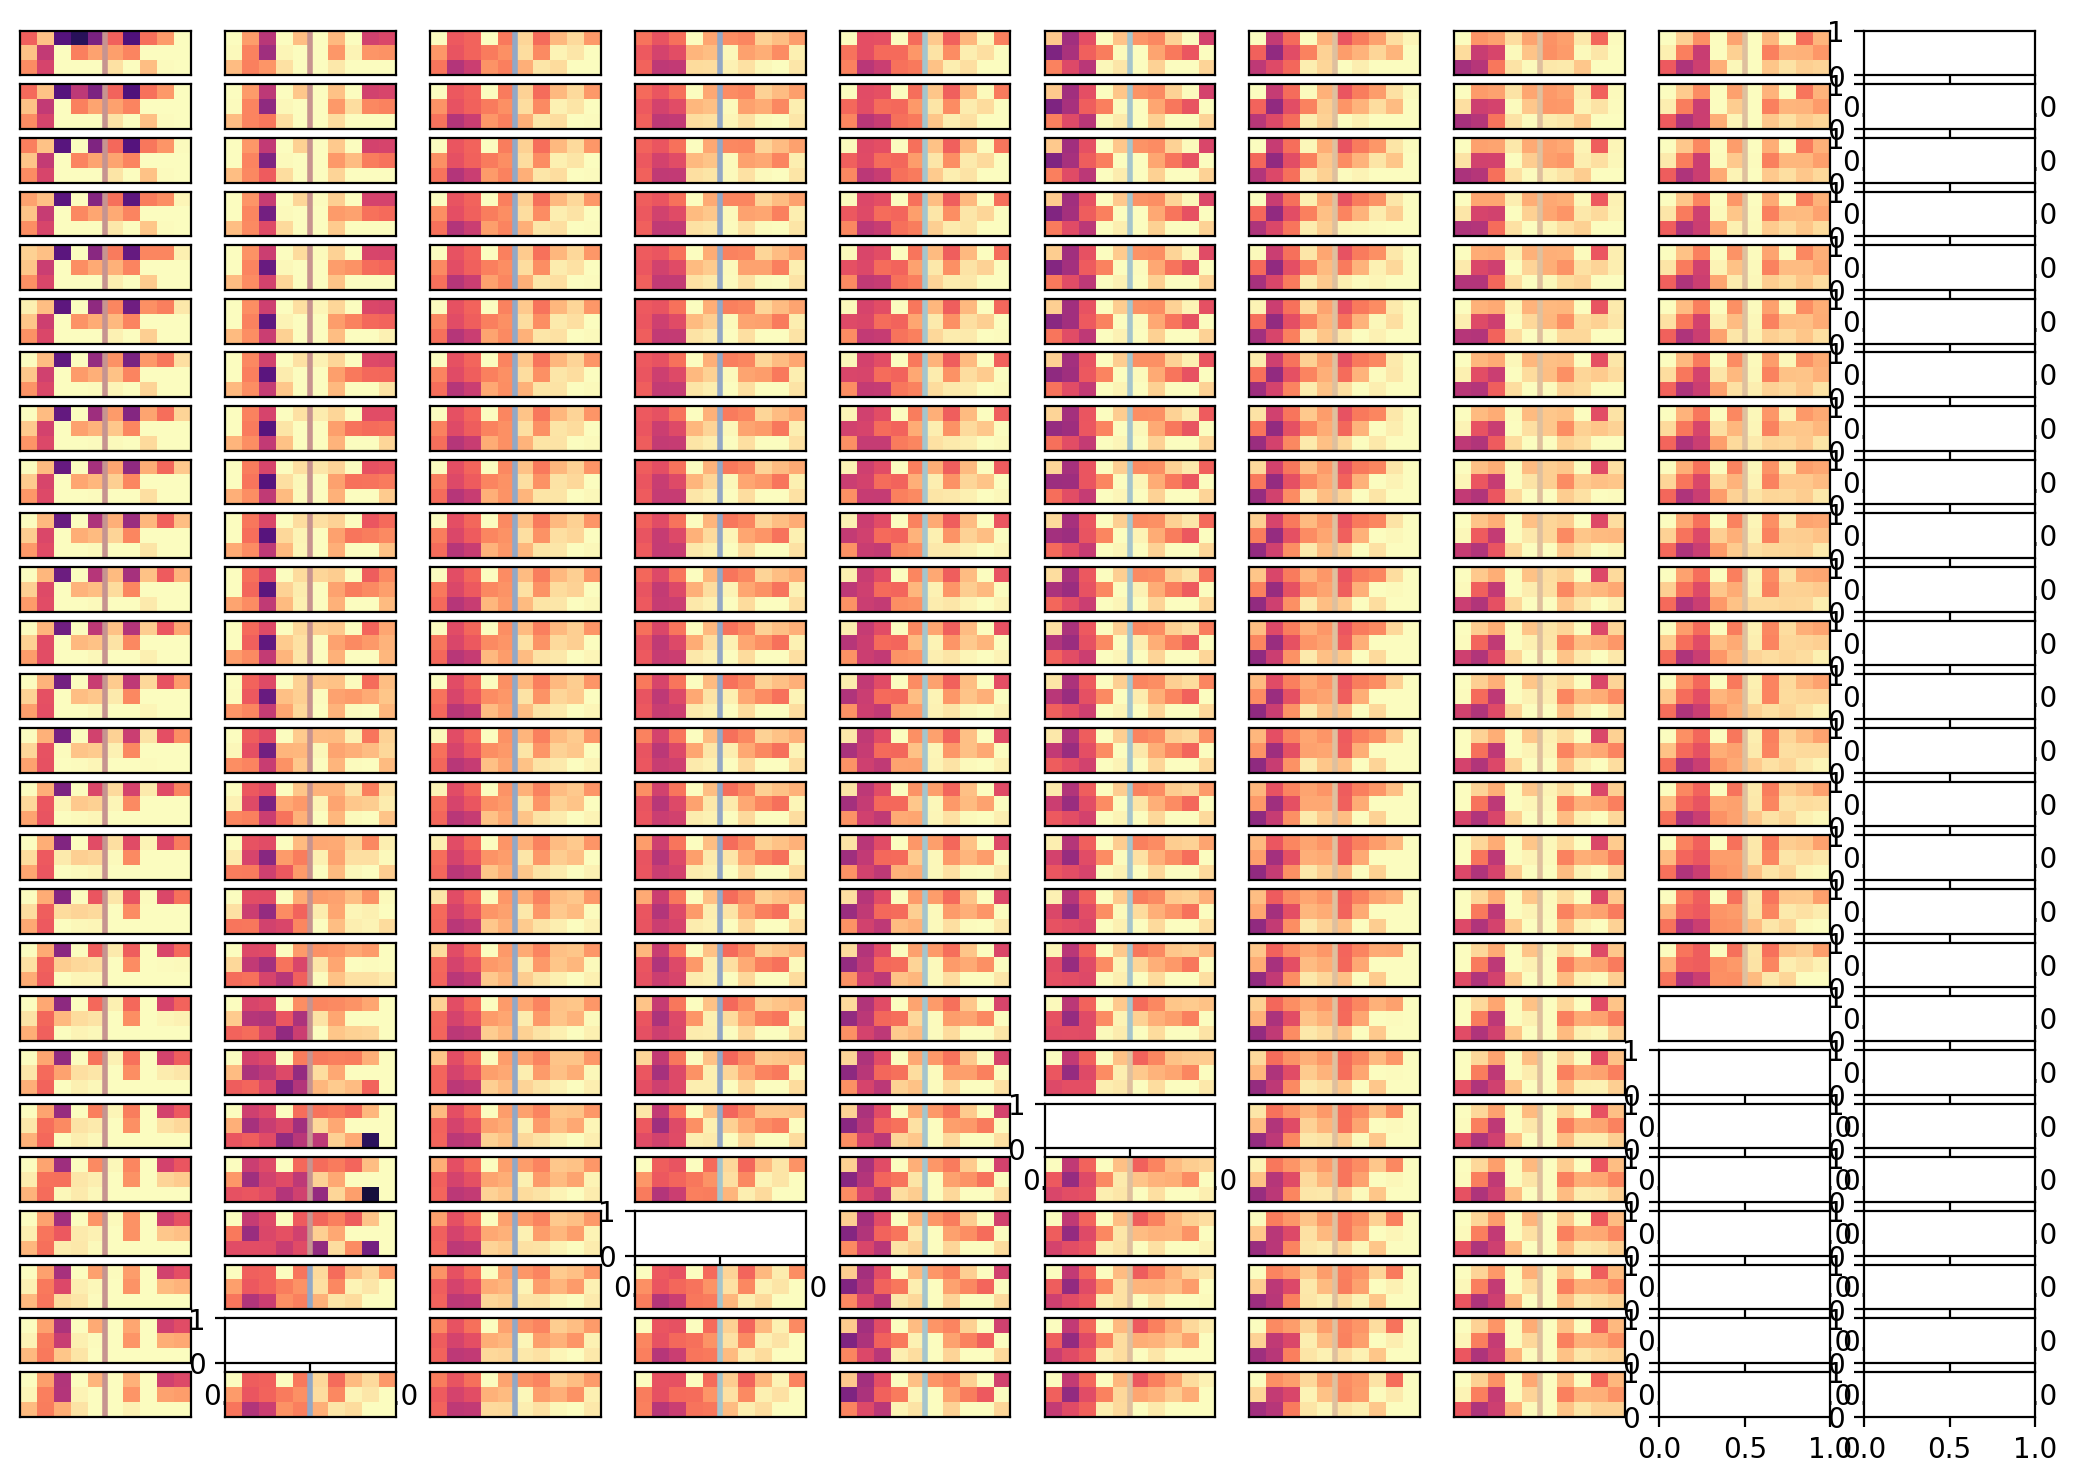

In [44]:
chromatin_gridder.create_deconvolution_plots(find_gamma_chromatin.f, model)

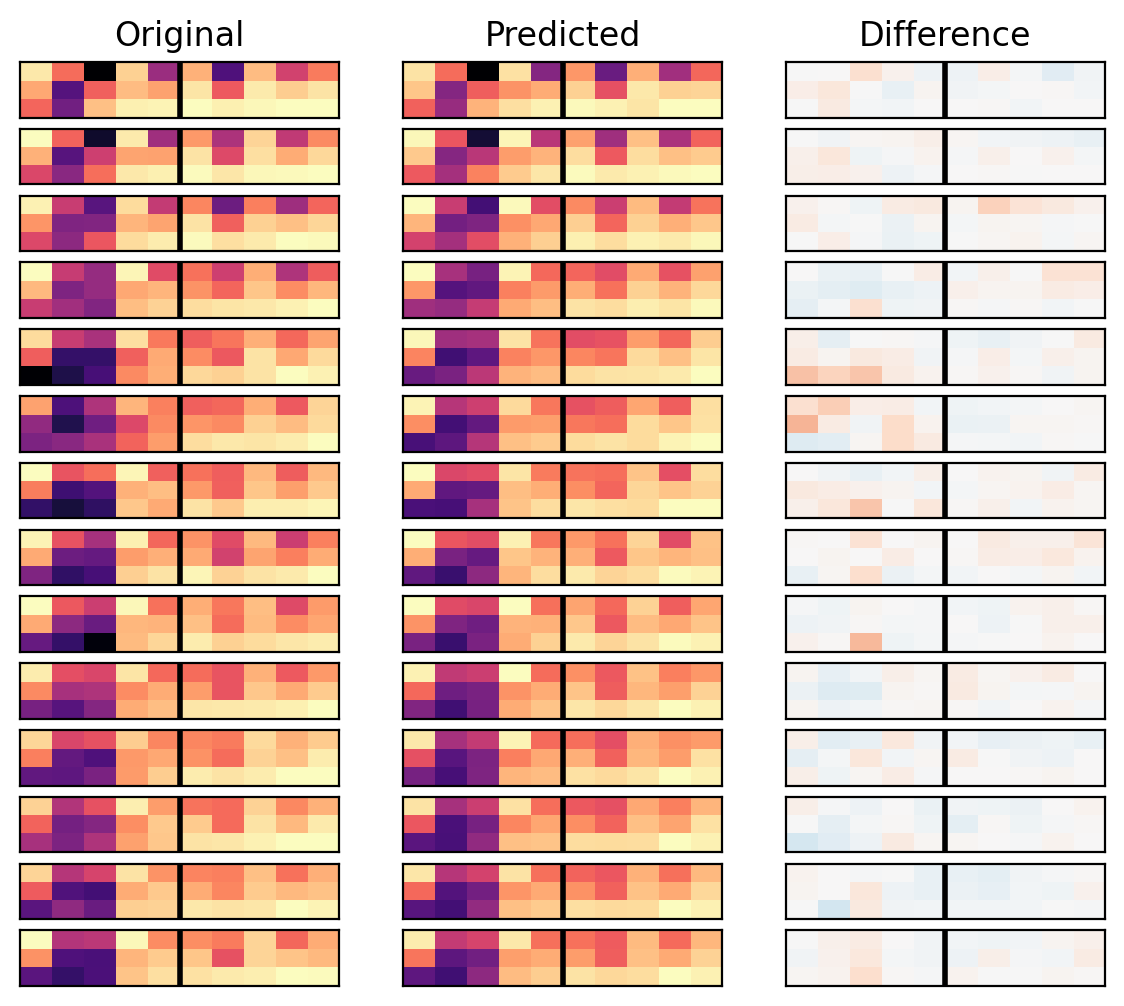

In [56]:
chromatin_gridder.plot_prediction_comparison(model, find_gamma_chromatin.f)

In [51]:
model.gamma

0.0055000000000000005

In [52]:
model.deconvolve()

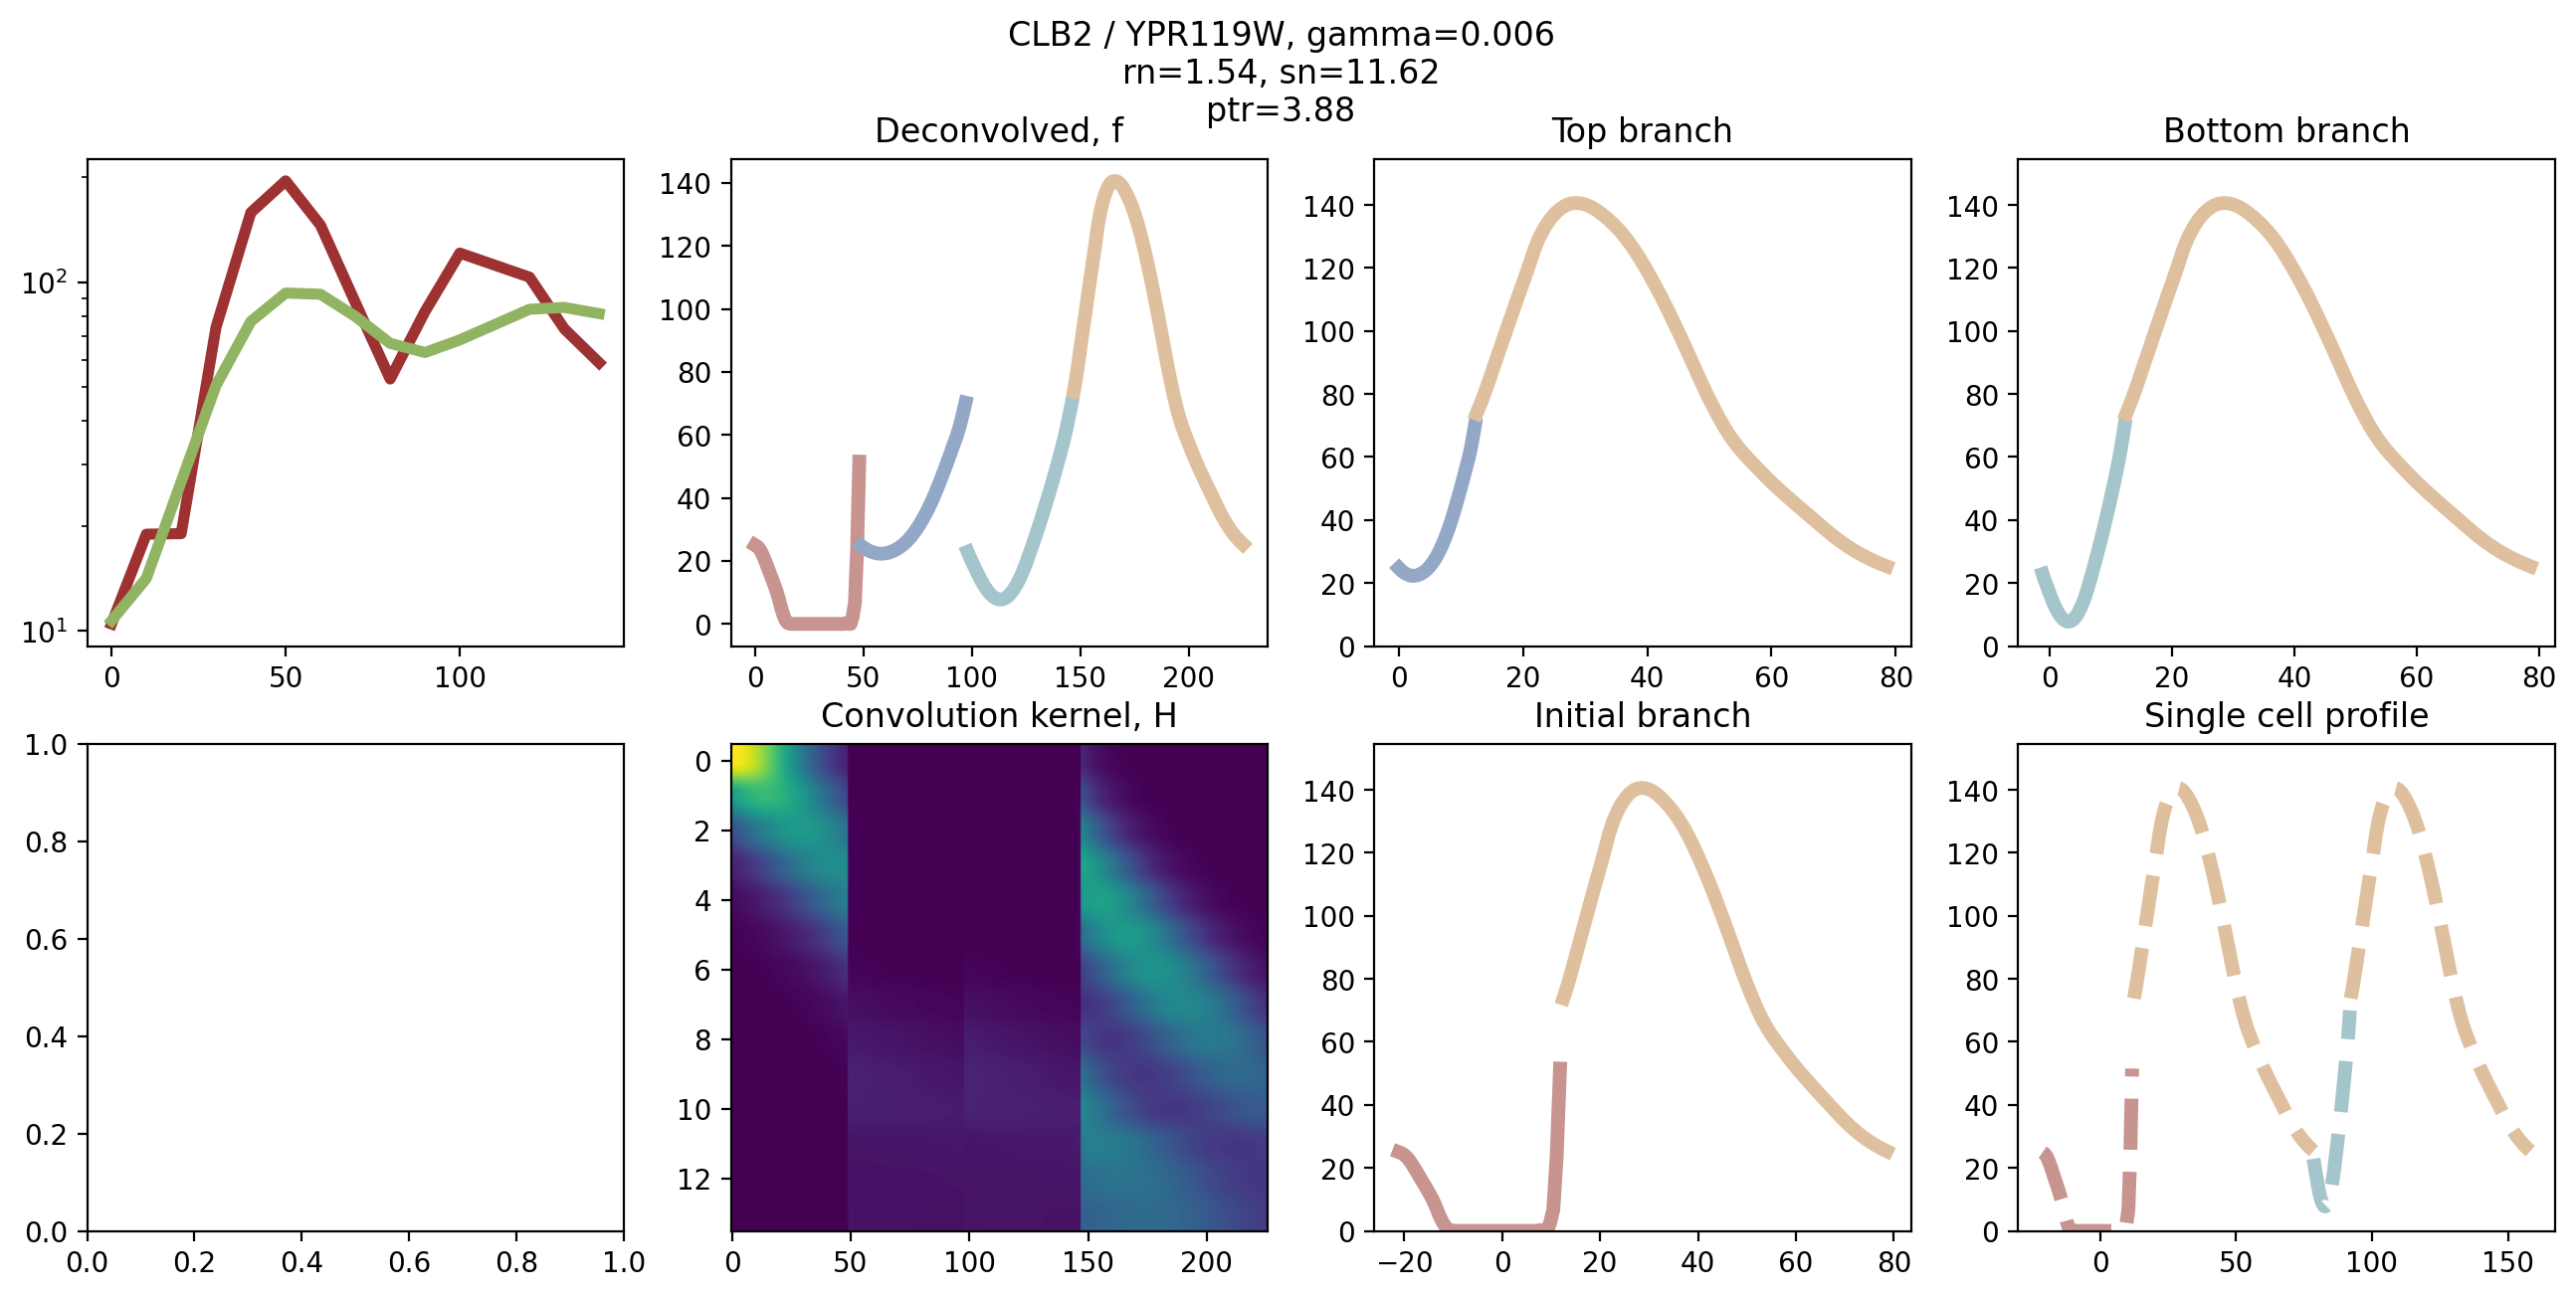

In [49]:
model.plot_deconvolved_gene()